# 06 — Ensemble Modeling and Final Selection

This notebook compares classic Gradient Boosting, AdaBoost, XGBoost, and Random Forest against the best single-tree baseline. The winner is selected on validation PR-AUC before the test set is evaluated.

## Install required packages

In [1]:
%pip install pandas numpy scikit-learn xgboost joblib matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import json
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import ParameterGrid
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score, brier_score_loss, classification_report,
    ConfusionMatrixDisplay, log_loss, precision_recall_curve,
    PrecisionRecallDisplay, RocCurveDisplay, roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from xgboost import XGBClassifier
from IPython.display import display, Markdown

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid")

current_dir = Path.cwd().resolve()
project_root = next(
    (path for path in [current_dir, *current_dir.parents] if (path / "data" / "processed" / "engineered").exists()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not find engineered data.")

engineered_dir = project_root / "data" / "processed" / "engineered"
baseline_dir = project_root / "models" / "baselines"
ensemble_dir = project_root / "models" / "ensembles"
ensemble_dir.mkdir(parents=True, exist_ok=True)

## Why these three ensembles?

- **Gradient Boosting:** builds classic decision trees sequentially so each new tree corrects earlier errors.
- **AdaBoost:** increases attention on observations that earlier weak trees classified incorrectly.
- **XGBoost:** regularized gradient boosting with row and feature sampling. It is often strong on structured tabular data.
- **Random Forest:** trains many randomized trees independently and averages them, mainly reducing the variance of one tree.

PR-AUC is the primary selection metric because only about 7% of impressions are clicks. ROC-AUC, log loss, Brier score, and top-decile lift provide additional evidence.

## Load training, validation, and test data

In [3]:
train = pd.read_csv(engineered_dir / "train_top6_engineered.csv", parse_dates=["event_ts"])
validation = pd.read_csv(engineered_dir / "validation_top6_engineered.csv", parse_dates=["event_ts"])
with (engineered_dir / "feature_metadata.json").open() as file:
    feature_metadata = json.load(file)

target = "clicked"
selected_derived_features = feature_metadata["selected_derived_features"]
display(pd.DataFrame([
    {"split": name, "rows": len(frame), "columns": frame.shape[1], "click_rate": frame[target].mean()}
    for name, frame in {"train": train, "validation": validation}.items()
]).set_index("split"))

,rows,columns,click_rate
split,,,
train,315000,28,0.0682
validation,67500,28,0.0701


## Prepare common model inputs

All models receive the same predictors and preprocessing. Raw user/product IDs are excluded here: historical behavior features represent them more safely and prevent arbitrary ordinal splits on identifier values.

In [4]:
numeric_features = [
    "slot_position", "hour_of_day", "price_usd", "discount_pct",
    "avg_rating", "review_count", "age", *selected_derived_features,
]
categorical_features = [
    "platform", "device_os", "page_type", "day_of_week",
    "brand", "category", "gender", "city", "loyalty_tier",
]
feature_columns = numeric_features + categorical_features

for frame in [train, validation]:
    frame.replace([np.inf, -np.inf], np.nan, inplace=True)
    for column in categorical_features:
        frame[column] = frame[column].astype("string")

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
], sparse_threshold=0.0)

X_train_raw, y_train = train[feature_columns], train[target].astype("int8")
X_validation_raw, y_validation = validation[feature_columns], validation[target].astype("int8")
X_train = preprocessor.fit_transform(X_train_raw).astype(np.float32)
X_validation = preprocessor.transform(X_validation_raw).astype(np.float32)
encoded_feature_names = preprocessor.get_feature_names_out().tolist()
print(f"Encoded shapes: train={X_train.shape}, validation={X_validation.shape}")

Encoded shapes: train=(315000, 22), validation=(67500, 22)


## Define the ensemble candidates

In [5]:
positive_weight = float((y_train == 0).sum() / (y_train == 1).sum())
base_models = {
    "gradient_boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "adaboost": AdaBoostClassifier(random_state=RANDOM_STATE),
    "xgboost": XGBClassifier(
        objective="binary:logistic", eval_metric="aucpr",
        n_estimators=400, learning_rate=0.05, max_depth=6,
        min_child_weight=20, subsample=0.8, colsample_bytree=0.8,
        reg_lambda=2.0, tree_method="hist", n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=250, max_depth=16, min_samples_leaf=50,
        max_features="sqrt", class_weight="balanced_subsample",
        n_jobs=-1, random_state=RANDOM_STATE,
    ),
}
parameter_grids = {
    "gradient_boosting": {
        "n_estimators": [100, 250], "learning_rate": [0.05, 0.10],
        "max_depth": [2, 3], "min_samples_leaf": [100],
        "subsample": [0.85], "max_features": [None],
    },
    "adaboost": {
        "n_estimators": [100, 250], "learning_rate": [0.03, 0.10, 0.50, 1.0],
    },
    "xgboost": {
        "n_estimators": [250, 500], "learning_rate": [0.03, 0.08],
        "max_depth": [3, 6], "min_child_weight": [20],
        "subsample": [0.85], "colsample_bytree": [0.85],
        "reg_alpha": [0.1], "reg_lambda": [2.0],
    },
    "random_forest": {
        "n_estimators": [150, 300], "max_depth": [12, 24],
        "min_samples_leaf": [25, 75], "max_features": ["sqrt"],
        "class_weight": ["balanced_subsample"],
    },
}
grid_sizes = {name: len(ParameterGrid(grid)) for name, grid in parameter_grids.items()}
display(pd.DataFrame([
    {"model_family": name, "grid_configurations": size, "parameters_tuned": list(parameter_grids[name])}
    for name, size in grid_sizes.items()
]).set_index("model_family"))
print(f"Training positive-class weight for reference: {positive_weight:.2f}")

,grid_configurations,parameters_tuned
model_family,,
gradient_boosting,8,"[n_estimators, learning_rate, max_depth, min_s..."
adaboost,8,"[n_estimators, learning_rate]"
xgboost,8,"[n_estimators, learning_rate, max_depth, min_c..."
random_forest,8,"[n_estimators, max_depth, min_samples_leaf, ma..."


Training positive-class weight for reference: 13.66


## Tune all four ensemble families

Each family evaluates eight parameter-grid configurations. Candidates are trained on training data and ranked with validation PR-AUC; test data is not used.

In [6]:
tuning_rows = []
models = {}
for family_name, base_model in base_models.items():
    print(f"\nTuning {family_name}...")
    best_score, best_candidate = -np.inf, None
    grid_candidates = list(ParameterGrid(parameter_grids[family_name]))
    for trial, parameters in enumerate(grid_candidates, start=1):
        candidate = base_model.__class__(**{**base_model.get_params(), **parameters})
        start = time.perf_counter()
        candidate.fit(X_train, y_train)
        fit_seconds = time.perf_counter() - start
        train_probability = candidate.predict_proba(X_train)[:, 1]
        validation_probability = candidate.predict_proba(X_validation)[:, 1]
        train_pr_auc = average_precision_score(y_train, train_probability)
        validation_pr_auc = average_precision_score(y_validation, validation_probability)
        tuning_rows.append({
            "model_family": family_name, "trial": trial,
            "parameters": json.dumps(parameters, sort_keys=True),
            "fit_seconds": fit_seconds, "train_pr_auc": train_pr_auc,
            "validation_pr_auc": validation_pr_auc,
            "pr_auc_gap": train_pr_auc - validation_pr_auc,
        })
        print(f"  Trial {trial}/{len(grid_candidates)}: validation PR-AUC={validation_pr_auc:.4f}")
        if validation_pr_auc > best_score:
            best_score, best_candidate = validation_pr_auc, candidate
    models[family_name] = best_candidate

tuning_results = pd.DataFrame(tuning_rows).sort_values(
    ["model_family", "validation_pr_auc"], ascending=[True, False]
)
best_tuning_results = tuning_results.groupby("model_family", as_index=False).first()
display(best_tuning_results.set_index("model_family"))


Tuning gradient_boosting...
  Trial 1/8: validation PR-AUC=0.2089
  Trial 2/8: validation PR-AUC=0.2234
  Trial 3/8: validation PR-AUC=0.2415
  Trial 4/8: validation PR-AUC=0.2628
  Trial 5/8: validation PR-AUC=0.2198
  Trial 6/8: validation PR-AUC=0.2556
  Trial 7/8: validation PR-AUC=0.2567
  Trial 8/8: validation PR-AUC=0.2766

Tuning adaboost...
  Trial 1/8: validation PR-AUC=0.1406
  Trial 2/8: validation PR-AUC=0.1724
  Trial 3/8: validation PR-AUC=0.1804
  Trial 4/8: validation PR-AUC=0.1908
  Trial 5/8: validation PR-AUC=0.1987
  Trial 6/8: validation PR-AUC=0.2045
  Trial 7/8: validation PR-AUC=0.2071
  Trial 8/8: validation PR-AUC=0.2102

Tuning xgboost...
  Trial 1/8: validation PR-AUC=0.2468
  Trial 2/8: validation PR-AUC=0.2641
  Trial 3/8: validation PR-AUC=0.2776
  Trial 4/8: validation PR-AUC=0.2828
  Trial 5/8: validation PR-AUC=0.2713
  Trial 6/8: validation PR-AUC=0.2826
  Trial 7/8: validation PR-AUC=0.2806
  Trial 8/8: validation PR-AUC=0.2770

Tuning random_fores

,trial,parameters,fit_seconds,train_pr_auc,validation_pr_auc,pr_auc_gap
model_family,,,,,,
adaboost,8,"{""learning_rate"": 1.0, ""n_estimators"": 250}",60.3751,0.1913,0.2102,-0.0189
gradient_boosting,8,"{""learning_rate"": 0.1, ""max_depth"": 3, ""max_fe...",141.8338,0.2679,0.2766,-0.0087
random_forest,6,"{""class_weight"": ""balanced_subsample"", ""max_de...",15.0660,0.5042,0.2691,0.2351
xgboost,4,"{""colsample_bytree"": 0.85, ""learning_rate"": 0....",1.9596,0.3114,0.2828,0.0286


## Train and compare on validation data

The best tuned configuration from each family is compared using training and validation metrics. No ensemble is evaluated on test data in this section.

In [7]:
def top_fraction_metrics(y_true, probability, fraction=0.10):
    cutoff = max(1, int(len(y_true) * fraction))
    top_indices = np.argsort(probability)[-cutoff:]
    y_array = np.asarray(y_true)
    top_ctr = float(y_array[top_indices].mean())
    base_ctr = float(y_array.mean())
    return top_ctr, top_ctr / base_ctr if base_ctr else np.nan

def probability_metrics(y_true, probability):
    top_ctr, top_lift = top_fraction_metrics(y_true, probability)
    return {
        "pr_auc": average_precision_score(y_true, probability),
        "roc_auc": roc_auc_score(y_true, probability),
        "log_loss": log_loss(y_true, probability),
        "brier_score": brier_score_loss(y_true, probability),
        "top_10pct_ctr": top_ctr,
        "top_10pct_lift": top_lift,
    }

results = []
validation_probabilities = {}
for name, model in models.items():
    print(f"Training {name}...")
    start = time.perf_counter()
    model.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - start
    train_probability = model.predict_proba(X_train)[:, 1]
    validation_probability = model.predict_proba(X_validation)[:, 1]
    validation_probabilities[name] = validation_probability
    train_metrics = probability_metrics(y_train, train_probability)
    validation_metrics = probability_metrics(y_validation, validation_probability)
    results.append({
        "model": name,
        "fit_seconds": fit_seconds,
        **{f"train_{key}": value for key, value in train_metrics.items()},
        **{f"validation_{key}": value for key, value in validation_metrics.items()},
        "pr_auc_gap": train_metrics["pr_auc"] - validation_metrics["pr_auc"],
    })

ensemble_results = pd.DataFrame(results).set_index("model").sort_values("validation_pr_auc", ascending=False)
display(ensemble_results)

Training gradient_boosting...
Training adaboost...
Training xgboost...
Training random_forest...


,fit_seconds,train_pr_auc,train_roc_auc,train_log_loss,train_brier_score,train_top_10pct_ctr,train_top_10pct_lift,validation_pr_auc,validation_roc_auc,validation_log_loss,validation_brier_score,validation_top_10pct_ctr,validation_top_10pct_lift,pr_auc_gap
model,,,,,,,,,,,,,,
xgboost,1.9620,0.3114,0.8293,0.1987,0.0547,0.3029,4.4395,0.2828,0.8021,0.2100,0.0573,0.2942,4.1970,0.0286
gradient_boosting,140.7934,0.2679,0.7947,0.2090,0.0566,0.2717,3.9831,0.2766,0.7967,0.2119,0.0577,0.2893,4.1272,-0.0087
random_forest,14.9750,0.5042,0.9371,0.3477,0.1017,0.4207,6.1668,0.2691,0.7908,0.3928,0.1206,0.2812,4.0110,0.2351
adaboost,60.2439,0.1913,0.7559,0.4582,0.1371,0.2200,3.2241,0.2102,0.7645,0.4549,0.1357,0.2394,3.4150,-0.0189


## Compare against the single decision-tree baseline

In [8]:
baseline_path = baseline_dir / "baseline_validation_results.csv"
if baseline_path.exists():
    baseline_results = pd.read_csv(baseline_path, index_col=0)
    decision_tree_baseline = baseline_results.loc["decision_tree"]
    comparison_columns = ["validation_pr_auc", "validation_roc_auc", "validation_log_loss", "validation_brier_score"]
    combined_results = pd.concat([
        baseline_results.loc[["decision_tree"], comparison_columns],
        ensemble_results[comparison_columns],
    ])
    display(combined_results.sort_values("validation_pr_auc", ascending=False))
else:
    baseline_results = None
    decision_tree_baseline = None
    display(Markdown("Baseline result file was not found. Run notebook 05 before making the final comparison."))

,validation_pr_auc,validation_roc_auc,validation_log_loss,validation_brier_score
model,,,,
xgboost,0.2828,0.8021,0.2100,0.0573
gradient_boosting,0.2766,0.7967,0.2119,0.0577
random_forest,0.2691,0.7908,0.3928,0.1206
decision_tree,0.2277,0.7643,0.5850,0.1981
adaboost,0.2102,0.7645,0.4549,0.1357


## Compare validation ranking and calibration

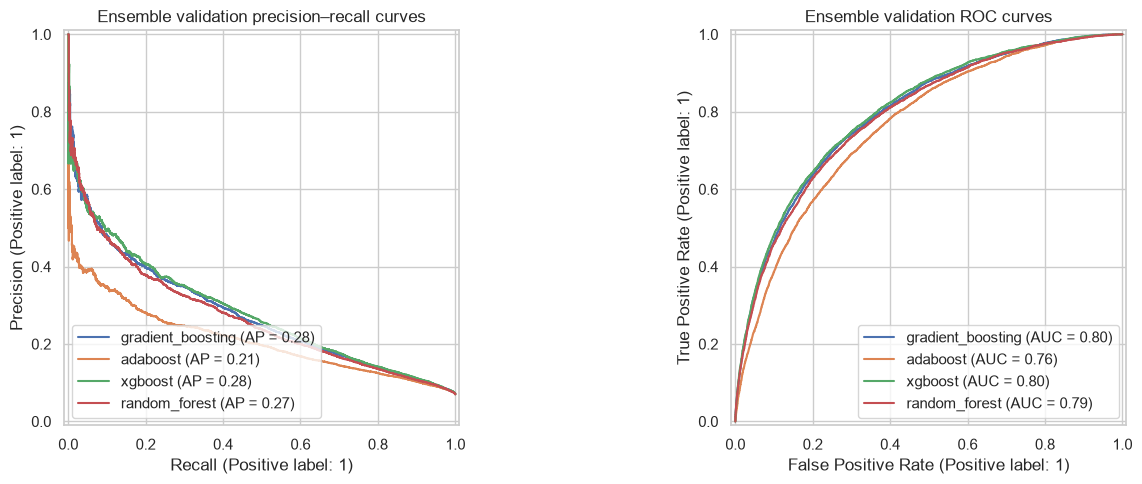

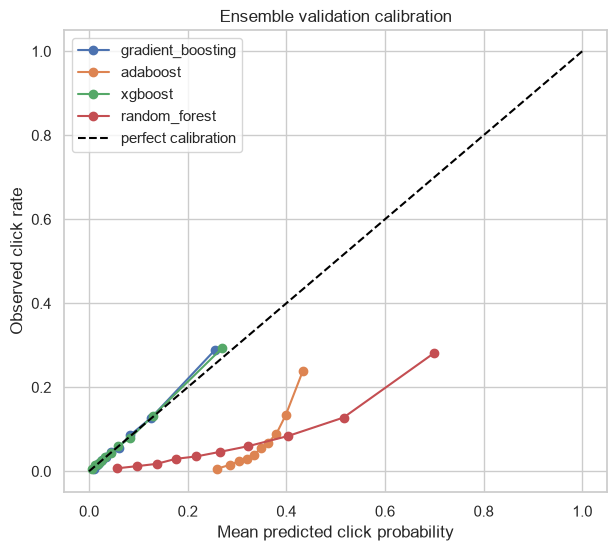

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, probability in validation_probabilities.items():
    PrecisionRecallDisplay.from_predictions(y_validation, probability, name=name, ax=axes[0])
    RocCurveDisplay.from_predictions(y_validation, probability, name=name, ax=axes[1])
axes[0].set_title("Ensemble validation precision–recall curves")
axes[1].set_title("Ensemble validation ROC curves")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
for name, probability in validation_probabilities.items():
    observed, predicted = calibration_curve(y_validation, probability, n_bins=10, strategy="quantile")
    plt.plot(predicted, observed, marker="o", label=name)
plt.plot([0, 1], [0, 1], "--", color="black", label="perfect calibration")
plt.xlabel("Mean predicted click probability")
plt.ylabel("Observed click rate")
plt.title("Ensemble validation calibration")
plt.legend()
plt.show()

## Select the best ensemble before touching test labels

In [10]:
best_ensemble_name = ensemble_results.index[0]
best_ensemble = models[best_ensemble_name]
best_validation_row = ensemble_results.loc[best_ensemble_name]

if decision_tree_baseline is not None:
    baseline_pr_auc = float(decision_tree_baseline["validation_pr_auc"])
    absolute_pr_auc_gain = best_validation_row["validation_pr_auc"] - baseline_pr_auc
    relative_pr_auc_gain = absolute_pr_auc_gain / baseline_pr_auc
    beats_baseline = absolute_pr_auc_gain > 0
else:
    baseline_pr_auc = np.nan
    absolute_pr_auc_gain = np.nan
    relative_pr_auc_gain = np.nan
    beats_baseline = None

selection_summary = pd.Series({
    "selected ensemble": best_ensemble_name,
    "validation PR-AUC": best_validation_row["validation_pr_auc"],
    "validation ROC-AUC": best_validation_row["validation_roc_auc"],
    "validation log loss": best_validation_row["validation_log_loss"],
    "validation Brier score": best_validation_row["validation_brier_score"],
    "validation top-10% lift": best_validation_row["validation_top_10pct_lift"],
    "absolute PR-AUC gain over tree": absolute_pr_auc_gain,
    "relative PR-AUC gain over tree": relative_pr_auc_gain,
})
display(selection_summary.to_frame("value"))

,value
selected ensemble,xgboost
validation PR-AUC,0.2828
validation ROC-AUC,0.8021
validation log loss,0.2100
validation Brier score,0.0573
validation top-10% lift,4.1970
absolute PR-AUC gain over tree,0.0552
relative PR-AUC gain over tree,0.2422


## Final test evaluation of the selected ensemble

Only the validation winner is evaluated here. The other candidates never see test results, preventing test-driven model selection.

,test value
pr_auc,0.2749
roc_auc,0.7954
log_loss,0.2132
brier_score,0.0581
top_10pct_ctr,0.2836
top_10pct_lift,4.0176


Threshold selected on validation only: 0.1634
              precision    recall  f1-score   support

           0     0.9535    0.9205    0.9367     62736
           1     0.2808    0.4085    0.3328      4764

    accuracy                         0.8844     67500
   macro avg     0.6171    0.6645    0.6348     67500
weighted avg     0.9060    0.8844    0.8941     67500



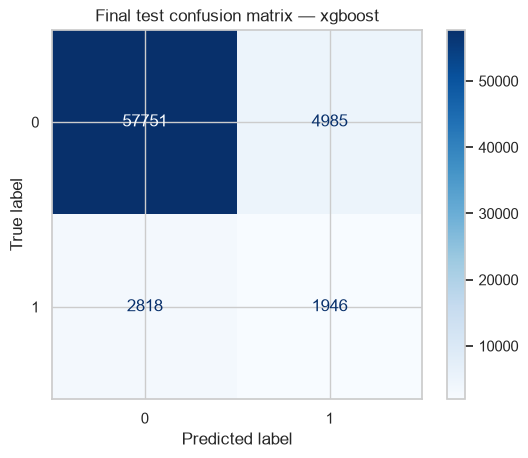

In [11]:
# Test data is loaded only after the validation winner has been fixed.
test = pd.read_csv(engineered_dir / "test_top6_engineered.csv", parse_dates=["event_ts"])
test.replace([np.inf, -np.inf], np.nan, inplace=True)
for column in categorical_features:
    test[column] = test[column].astype("string")
X_test = preprocessor.transform(test[feature_columns]).astype(np.float32)
y_test = test[target].astype("int8")
test_probability = best_ensemble.predict_proba(X_test)[:, 1]
test_metrics = probability_metrics(y_test, test_probability)
display(pd.Series(test_metrics, name="test value").to_frame())

precision, recall, thresholds = precision_recall_curve(y_validation, validation_probabilities[best_ensemble_name])
f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
selected_threshold = float(thresholds[int(np.nanargmax(f1))])
test_prediction = (test_probability >= selected_threshold).astype(int)
print(f"Threshold selected on validation only: {selected_threshold:.4f}")
print(classification_report(y_test, test_prediction, digits=4))
ConfusionMatrixDisplay.from_predictions(y_test, test_prediction, cmap="Blues")
plt.title(f"Final test confusion matrix — {best_ensemble_name}")
plt.show()

## Feature importance for the winning ensemble

,importance
numeric__product_past_ctr,0.2301
numeric__slot_position,0.1331
numeric__category_past_ctr,0.0876
categorical__category,0.0651
categorical__gender,0.0617
numeric__avg_rating,0.0463
numeric__age,0.0439
numeric__user_product_ctr_gap,0.0397
categorical__page_type,0.0358
numeric__category_page_ctr_gap,0.0314


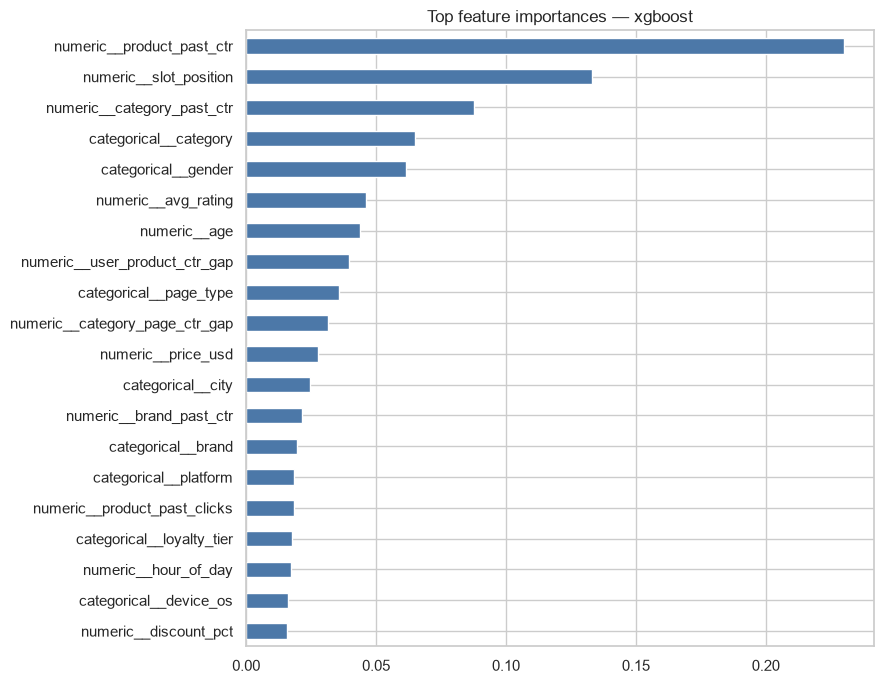

In [12]:
if hasattr(best_ensemble, "feature_importances_"):
    importance = (
        pd.Series(best_ensemble.feature_importances_, index=encoded_feature_names, name="importance")
        .sort_values(ascending=False)
        .head(20)
    )
    display(importance.to_frame())
    importance.sort_values().plot(kind="barh", figsize=(9, 7), color="#4C78A8")
    plt.title(f"Top feature importances — {best_ensemble_name}")
    plt.tight_layout()
    plt.show()
else:
    display(Markdown("Histogram Gradient Boosting does not expose impurity-based feature importance. Use permutation importance or SHAP in a separate interpretation step."))

## Save the winner and comparison results

In [13]:
joblib.dump(preprocessor, ensemble_dir / "preprocessor.joblib")
joblib.dump(best_ensemble, ensemble_dir / "best_ensemble.joblib")
ensemble_results.to_csv(ensemble_dir / "ensemble_validation_results.csv")
tuning_results.to_csv(ensemble_dir / "hyperparameter_tuning_results.csv", index=False)

final_metadata = {
    "selected_model": best_ensemble_name,
    "selection_metric": "validation_pr_auc",
    "tuning_trials_per_family": grid_sizes,
    "best_parameters_by_family": {name: model.get_params() for name, model in models.items()},
    "selected_threshold_from_validation": selected_threshold,
    "selected_derived_features": selected_derived_features,
    "validation_metrics": {key: float(value) for key, value in best_validation_row.items()},
    "test_metrics": {key: float(value) for key, value in test_metrics.items()},
    "decision_tree_baseline_pr_auc": baseline_pr_auc,
    "absolute_validation_pr_auc_gain": absolute_pr_auc_gain,
    "relative_validation_pr_auc_gain": relative_pr_auc_gain,
}
with (ensemble_dir / "ensemble_metadata.json").open("w") as file:
    json.dump(final_metadata, file, indent=2)
print(f"Saved final ensemble artifacts to: {ensemble_dir}")

Saved final ensemble artifacts to: /Users/namees.local/Desktop/ensamble_technique/models/ensembles


## Final ensemble recap

In [14]:
baseline_statement = (
    f"It {'beat' if beats_baseline else 'did not beat'} the decision-tree baseline by {absolute_pr_auc_gain:+.4f} absolute validation PR-AUC ({relative_pr_auc_gain:+.2%} relative)."
    if beats_baseline is not None else "The saved decision-tree baseline was unavailable, so rerun notebook 05 for that comparison."
)

display(Markdown(f"""
### Best model

- The validation winner is **{best_ensemble_name}**.
- Validation: PR-AUC **{best_validation_row['validation_pr_auc']:.4f}**, ROC-AUC **{best_validation_row['validation_roc_auc']:.4f}**, log loss **{best_validation_row['validation_log_loss']:.4f}**, Brier score **{best_validation_row['validation_brier_score']:.4f}**, and top-10% lift **{best_validation_row['validation_top_10pct_lift']:.2f}×**.
- {baseline_statement}
- Final test: PR-AUC **{test_metrics['pr_auc']:.4f}**, ROC-AUC **{test_metrics['roc_auc']:.4f}**, log loss **{test_metrics['log_loss']:.4f}**, Brier score **{test_metrics['brier_score']:.4f}**, and top-10% lift **{test_metrics['top_10pct_lift']:.2f}×**.

### Decision

Select this ensemble only if its validation improvement is meaningful and its probability metrics are acceptable. If it does not beat the decision tree, keep the simpler tree rather than choosing complexity for its own sake.

The saved model should next receive probability calibration, interpretation, and business-oriented ranking evaluation before deployment.
"""))


### Best model

- The validation winner is **xgboost**.
- Validation: PR-AUC **0.2828**, ROC-AUC **0.8021**, log loss **0.2100**, Brier score **0.0573**, and top-10% lift **4.20×**.
- It beat the decision-tree baseline by +0.0552 absolute validation PR-AUC (+24.22% relative).
- Final test: PR-AUC **0.2749**, ROC-AUC **0.7954**, log loss **0.2132**, Brier score **0.0581**, and top-10% lift **4.02×**.

### Decision

Select this ensemble only if its validation improvement is meaningful and its probability metrics are acceptable. If it does not beat the decision tree, keep the simpler tree rather than choosing complexity for its own sake.

The saved model should next receive probability calibration, interpretation, and business-oriented ranking evaluation before deployment.
